# Лабораторная работа 5


In [22]:
!pip install numpy scipy matplotlib pandas simpy -q

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, eig
from scipy.integrate import odeint
import pandas as pd
import simpy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (14, 8)

print("=" * 80)
print("ГЕНЕРАЦИЯ ПАРАМЕТРОВ ДЛЯ ВАРИАНТА 19")
print("=" * 80)

np.random.seed(19 + 643)

n = np.random.choice([2, 3, 4], 1)[0]
m = np.random.choice(range(4, 19), 1)[0]
mu = np.random.uniform(0, 1)
lambda_arr = np.random.uniform(0, 1)

if lambda_arr > mu:
    lambda_arr, mu = mu, lambda_arr

gamma = np.random.uniform(0, 1)
nu = np.random.uniform(0, 1)

if gamma < nu:
    nu, gamma = gamma, nu

if np.random.choice([0, 1], 1)[0] == 1:
    k = np.random.choice(range(4, 8), 1)[0]
else:
    k = float('inf')

t = np.random.uniform(0, 1)

print(f"\nСгенерированные параметры для варианта 19:")
print("-" * 50)
print(f"  • Количество каналов (n) = {n}")
print(f"  • Длина очереди (m) = {m}")
print(f"  • Интенсивность входа (λ) = {lambda_arr:.6f} заявок/ед.времени")
print(f"  • Интенсивность обслуживания (μ) = {mu:.6f} заявок/ед.времени")
print(f"  • Интенсивность отказов канала (ν) = {nu:.6f}")
print(f"  • Интенсивность восстановления (γ) = {gamma:.6f}")
print(f"  • Количество источников (k) = {k if k == float('inf') else int(k)}")
print(f"  • Момент времени (t) = {t:.6f}")

print(f"\nРасчётные параметры:")
print(f"  • Загрузка системы (ρ) = {lambda_arr/(n*mu):.4f}")
print(f"  • Среднее время между отказами = {1/nu:.2f}")
print(f"  • Среднее время восстановления = {1/gamma:.2f}")

ГЕНЕРАЦИЯ ПАРАМЕТРОВ ДЛЯ ВАРИАНТА 19

Сгенерированные параметры для варианта 19:
--------------------------------------------------
  • Количество каналов (n) = 4
  • Длина очереди (m) = 14
  • Интенсивность входа (λ) = 0.020125 заявок/ед.времени
  • Интенсивность обслуживания (μ) = 0.506321 заявок/ед.времени
  • Интенсивность отказов канала (ν) = 0.522274
  • Интенсивность восстановления (γ) = 0.659850
  • Количество источников (k) = 5
  • Момент времени (t) = 0.220109

Расчётные параметры:
  • Загрузка системы (ρ) = 0.0099
  • Среднее время между отказами = 1.91
  • Среднее время восстановления = 1.52


ОПИСАНИЕ МОДЕЛИ

МОДЕЛЬ: 4-канальная СМО с ограничением на длину очереди 14
        с отказами и восстановлением каналов

ОСОБЕННОСТИ МОДЕЛИ:
1. Входящий поток - простейший с интенсивностью λ = 0.0201
2. Время обслуживания - экспоненциальное с μ = 0.5063
3. Каждый канал может выходить из строя с интенсивностью ν = 0.5223
4. Восстановление канала происходит с интенсивностью γ = 0.6599
5. Длина очереди ограничена: не более 14 заявок
6. При отказе канала заявка на нём ставится в очередь (если есть место)
7. Если очередь заполнена - заявка покидает систему необслуженной
8. Источников заявок: 5 (конечное число)

СОСТОЯНИЯ СИСТЕМЫ:
Состояние определяется двумя параметрами:
- i: количество работающих каналов (0..n)
- j: количество заявок в системе (0..n+m)

Всего состояний: (n+1)*(n+m+1)

ДИАГРАММА ПЕРЕХОДОВ (упрощённая):

Для каждого работающего канала (i):
1. Поступление заявки: i → i (свободный канал) или в очередь
2. Обслуживание заявки: i → i (завершение обслуживания)
3. Отказ канала: i 

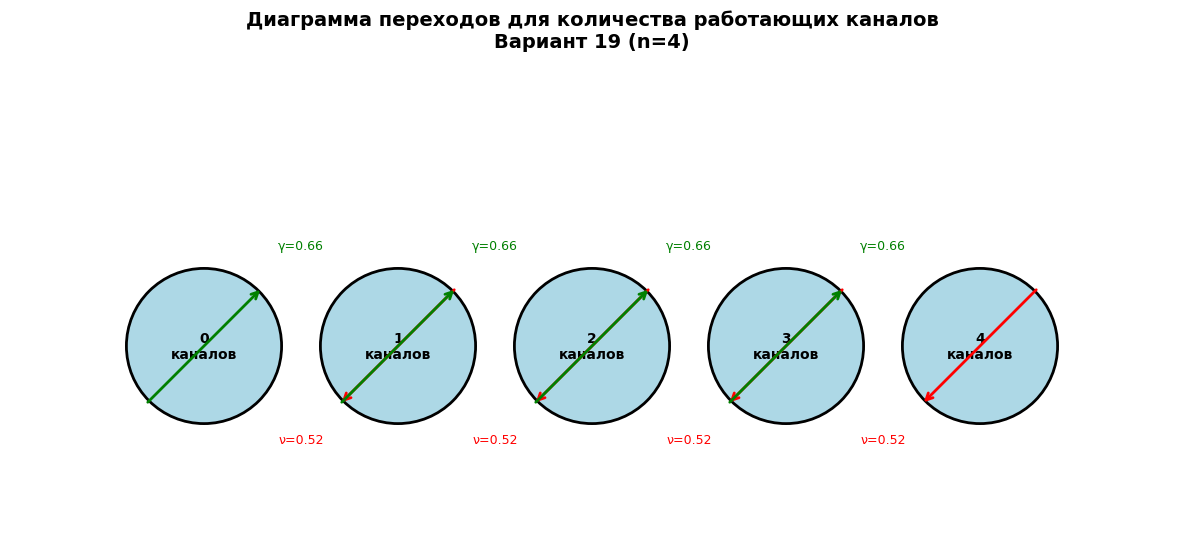

In [23]:

print("=" * 80)
print("ОПИСАНИЕ МОДЕЛИ")
print("=" * 80)

print(f"""
МОДЕЛЬ: {n}-канальная СМО с ограничением на длину очереди {m}
        с отказами и восстановлением каналов

ОСОБЕННОСТИ МОДЕЛИ:
1. Входящий поток - простейший с интенсивностью λ = {lambda_arr:.4f}
2. Время обслуживания - экспоненциальное с μ = {mu:.4f}
3. Каждый канал может выходить из строя с интенсивностью ν = {nu:.4f}
4. Восстановление канала происходит с интенсивностью γ = {gamma:.4f}
5. Длина очереди ограничена: не более {m} заявок
6. При отказе канала заявка на нём ставится в очередь (если есть место)
7. Если очередь заполнена - заявка покидает систему необслуженной
8. Источников заявок: {k if k == float('inf') else int(k)} {'(бесконечно)' if k == float('inf') else '(конечное число)'}

СОСТОЯНИЯ СИСТЕМЫ:
Состояние определяется двумя параметрами:
- i: количество работающих каналов (0..n)
- j: количество заявок в системе (0..n+m)

Всего состояний: (n+1)*(n+m+1)

ДИАГРАММА ПЕРЕХОДОВ (упрощённая):

Для каждого работающего канала (i):
1. Поступление заявки: i → i (свободный канал) или в очередь
2. Обслуживание заявки: i → i (завершение обслуживания)
3. Отказ канала: i → i-1 (канал ломается)
4. Восстановление: i → i+1 (канал чинится)
""")


def draw_simple_diagram(n, m):
    """Рисует упрощённую диаграмму состояний"""
    fig, ax = plt.subplots(figsize=(12, 6))

    states = list(range(n + 1))
    pos = {i: (i, 0) for i in states}

    for state in states:
        circle = plt.Circle((state, 0), 0.4, color='lightblue', ec='black', linewidth=2)
        ax.add_patch(circle)
        ax.text(state, 0, f"{state}\nканалов", ha='center', va='center', fontsize=10, fontweight='bold')

    for i in range(1, n+1):
        ax.annotate('', xy=(i-0.3, -0.3), xytext=(i+0.3, 0.3),
                   arrowprops=dict(arrowstyle='->', color='red', lw=2))
        ax.text(i-0.5, -0.5, f'ν={nu:.2f}', fontsize=9, color='red', ha='center')

    for i in range(n):
        ax.annotate('', xy=(i+0.3, 0.3), xytext=(i-0.3, -0.3),
                   arrowprops=dict(arrowstyle='->', color='green', lw=2))
        ax.text(i+0.5, 0.5, f'γ={gamma:.2f}', fontsize=9, color='green', ha='center')

    ax.set_xlim(-1, n+1)
    ax.set_ylim(-1, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'Диаграмма переходов для количества работающих каналов\nВариант 19 (n={n})',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

draw_simple_diagram(n, m)

In [24]:

print("=" * 80)
print("СИСТЕМА ДИФФЕРЕНЦИАЛЬНЫХ УРАВНЕНИЙ")
print("=" * 80)

print("""
Обозначения:
- P(i, j, t) - вероятность того, что в момент t работают i каналов и в системе j заявок
- i = 0..n (количество работающих каналов)
- j = 0..(n+m) (общее количество заявок в системе)

Интенсивности переходов:

1. ПОСТУПЛЕНИЕ ЗАЯВКИ:
   - Если i > 0 и j < n+m: (i, j) → (i, j+1) с интенсивностью λ
   - Если i = 0: заявка отклоняется (нет работающих каналов)

2. ОБСЛУЖИВАНИЕ ЗАЯВКИ (только если есть заявки и работающие каналы):
   - (i, j) → (i, j-1) с интенсивностью min(i, j) * μ

3. ОТКАЗ КАНАЛА (если i > 0):
   - (i, j) → (i-1, j) с интенсивностью i * ν
   - При этом заявка, обслуживаемая на отказавшем канале,
     становится в очередь (если есть место) или теряется

4. ВОССТАНОВЛЕНИЕ КАНАЛА (если i < n):
   - (i, j) → (i+1, j) с интенсивностью (n-i) * γ

УРАВНЕНИЯ КОЛМОГОРОВА:

dP(i,j)/dt =
    + λ * P(i, j-1)                    [поступление, если j>0]
    + min(i+1, j+1) * μ * P(i+1, j+1)  [завершение обслуживания]
    + (i+1) * ν * P(i+1, j)            [отказ канала]
    + (n-i+1) * γ * P(i-1, j)          [восстановление канала]
    - [λ + min(i,j)*μ + i*ν + (n-i)*γ] * P(i, j)

Граничные условия:
- P(i, j) = 0 для j < 0 или j > n+m
- P(i, j) = 0 для i < 0 или i > n
- ∑_{i=0..n} ∑_{j=0..n+m} P(i, j) = 1
""")

states = []
for i in range(n + 1):
    for j in range(n + m + 1):
        states.append((i, j))

n_states = len(states)
print(f"\nОбщее количество состояний: {n_states}")
print(f"  • i = 0..{n} (работающие каналы)")
print(f"  • j = 0..{n+m} (заявки в системе)")

СИСТЕМА ДИФФЕРЕНЦИАЛЬНЫХ УРАВНЕНИЙ

Обозначения:
- P(i, j, t) - вероятность того, что в момент t работают i каналов и в системе j заявок
- i = 0..n (количество работающих каналов)
- j = 0..(n+m) (общее количество заявок в системе)

Интенсивности переходов:

1. ПОСТУПЛЕНИЕ ЗАЯВКИ:
   - Если i > 0 и j < n+m: (i, j) → (i, j+1) с интенсивностью λ
   - Если i = 0: заявка отклоняется (нет работающих каналов)

2. ОБСЛУЖИВАНИЕ ЗАЯВКИ (только если есть заявки и работающие каналы):
   - (i, j) → (i, j-1) с интенсивностью min(i, j) * μ

3. ОТКАЗ КАНАЛА (если i > 0):
   - (i, j) → (i-1, j) с интенсивностью i * ν
   - При этом заявка, обслуживаемая на отказавшем канале,
     становится в очередь (если есть место) или теряется

4. ВОССТАНОВЛЕНИЕ КАНАЛА (если i < n):
   - (i, j) → (i+1, j) с интенсивностью (n-i) * γ

УРАВНЕНИЯ КОЛМОГОРОВА:

dP(i,j)/dt =
    + λ * P(i, j-1)                    [поступление, если j>0]
    + min(i+1, j+1) * μ * P(i+1, j+1)  [завершение обслуживания]
    + (i+1) * ν * P(i

In [25]:

def build_rate_matrix(n, m, lambda_arr, mu, nu, gamma):
    """
    Построение матрицы интенсивностей переходов Q
    Размер: (n+1)*(n+m+1) x (n+1)*(n+m+1)
    """
    states = []
    for i in range(n + 1):
        for j in range(n + m + 1):
            states.append((i, j))

    state_to_idx = {state: idx for idx, state in enumerate(states)}
    n_states = len(states)
    Q = np.zeros((n_states, n_states))

    for idx, (i, j) in enumerate(states):
        total_rate = 0

        if i > 0 and j < n + m:
            target_state = (i, j + 1)
            if target_state in state_to_idx:
                rate = lambda_arr
                Q[idx, state_to_idx[target_state]] = rate
                total_rate += rate

        if j > 0:
            serv_rate = min(i, j) * mu
            if serv_rate > 0:
                target_state = (i, j - 1)
                if target_state in state_to_idx:
                    Q[idx, state_to_idx[target_state]] = serv_rate
                    total_rate += serv_rate

        if i > 0:
            fail_rate = i * nu
            target_state = (i - 1, j)
            if target_state in state_to_idx:
                Q[idx, state_to_idx[target_state]] = fail_rate
                total_rate += fail_rate

        if i < n:
            repair_rate = (n - i) * gamma
            target_state = (i + 1, j)
            if target_state in state_to_idx:
                Q[idx, state_to_idx[target_state]] = repair_rate
                total_rate += repair_rate

        Q[idx, idx] = -total_rate

    return Q, states

Q, states_list = build_rate_matrix(n, m, lambda_arr, mu, nu, gamma)

print("=" * 80)
print("МАТРИЦА ИНТЕНСИВНОСТЕЙ ПЕРЕХОДОВ")
print("=" * 80)
print(f"Размер матрицы: {Q.shape[0]} x {Q.shape[1]}")
print(f"\nПервые 10x10 элементов матрицы Q:")
print("-" * 50)

for i in range(min(10, Q.shape[0])):
    row_str = ""
    for j in range(min(10, Q.shape[1])):
        val = Q[i, j]
        if abs(val) < 1e-10:
            row_str += "    0    "
        else:
            row_str += f"{val:8.3f} "
    print(f"Состояние {states_list[i]}: {row_str}")

МАТРИЦА ИНТЕНСИВНОСТЕЙ ПЕРЕХОДОВ
Размер матрицы: 95 x 95

Первые 10x10 элементов матрицы Q:
--------------------------------------------------
Состояние (0, 0):   -2.639     0        0        0        0        0        0        0        0        0    
Состояние (0, 1):     0      -2.639     0        0        0        0        0        0        0        0    
Состояние (0, 2):     0        0      -2.639     0        0        0        0        0        0        0    
Состояние (0, 3):     0        0        0      -2.639     0        0        0        0        0        0    
Состояние (0, 4):     0        0        0        0      -2.639     0        0        0        0        0    
Состояние (0, 5):     0        0        0        0        0      -2.639     0        0        0        0    
Состояние (0, 6):     0        0        0        0        0        0      -2.639     0        0        0    
Состояние (0, 7):     0        0        0        0        0        0        0      -2.639     

In [26]:

def solve_kolmogorov(Q, P0, t_eval):
    """
    Решение системы дифференциальных уравнений dP/dt = P * Q
    Используем матричную экспоненту: P(t) = P(0) * exp(Q*t)
    """
    n_states = Q.shape[0]
    results = np.zeros((len(t_eval), n_states))

    for idx, t_val in enumerate(t_eval):
        from scipy.linalg import expm
        exp_Qt = expm(Q * t_val)
        results[idx] = P0 @ exp_Qt

    return results

n_states = len(states_list)
P0 = np.zeros(n_states)
for idx, (i, j) in enumerate(states_list):
    if i == n and j == 0:
        P0[idx] = 1
        initial_state_idx = idx
        break

print("=" * 80)
print("РЕШЕНИЕ ДИФФЕРЕНЦИАЛЬНЫХ УРАВНЕНИЙ")
print("=" * 80)
print(f"Начальное состояние: i={n}, j=0 (все каналы работают, система пуста)")
print(f"Момент времени t = {t:.6f}")

t_eval = np.linspace(0, max(t, 1.0), 100)

P_t = solve_kolmogorov(Q, P0, t_eval)

t_idx = np.argmin(np.abs(t_eval - t))
P_at_t = P_t[t_idx]

print(f"\nВероятности состояний в момент t = {t:.6f}:")
print("-" * 60)
prob_with_state = [(P_at_t[idx], states_list[idx]) for idx in range(n_states) if P_at_t[idx] > 0.001]
prob_with_state.sort(reverse=True)
for prob, state in prob_with_state[:10]:
    print(f"  P(i={state[0]}, j={state[1]}) = {prob:.6f} ({prob*100:.2f}%)")

eigenvals, eigenvecs = np.linalg.eig(Q.T)
idx_stationary = np.argmin(np.abs(eigenvals))
stationary_dist = np.real(eigenvecs[:, idx_stationary])
stationary_dist = stationary_dist / np.sum(stationary_dist)

print(f"\nСтационарное распределение (t → ∞):")
print("-" * 60)
stationary_with_state = [(stationary_dist[idx], states_list[idx]) for idx in range(n_states) if stationary_dist[idx] > 0.001]
stationary_with_state.sort(reverse=True)
for prob, state in stationary_with_state[:10]:
    print(f"  P(i={state[0]}, j={state[1]}) = {prob:.6f} ({prob*100:.2f}%)")

РЕШЕНИЕ ДИФФЕРЕНЦИАЛЬНЫХ УРАВНЕНИЙ
Начальное состояние: i=4, j=0 (все каналы работают, система пуста)
Момент времени t = 0.220109

Вероятности состояний в момент t = 0.220109:
------------------------------------------------------------
  P(i=4, j=0) = 0.647346 (64.73%)
  P(i=3, j=0) = 0.294336 (29.43%)
  P(i=2, j=0) = 0.050186 (5.02%)
  P(i=1, j=0) = 0.003803 (0.38%)
  P(i=4, j=1) = 0.002738 (0.27%)
  P(i=3, j=1) = 0.001245 (0.12%)

Стационарное распределение (t → ∞):
------------------------------------------------------------
  P(i=2, j=0) = 0.350653 (35.07%)
  P(i=3, j=0) = 0.295352 (29.54%)
  P(i=1, j=0) = 0.185024 (18.50%)
  P(i=4, j=0) = 0.093289 (9.33%)
  P(i=0, j=0) = 0.036612 (3.66%)
  P(i=2, j=1) = 0.013942 (1.39%)
  P(i=3, j=1) = 0.011750 (1.18%)
  P(i=1, j=1) = 0.007335 (0.73%)
  P(i=4, j=1) = 0.003712 (0.37%)
  P(i=0, j=1) = 0.001451 (0.15%)


In [27]:

print("=" * 80)
print("ХАРАКТЕРИСТИКИ СИСТЕМЫ")
print("=" * 80)

def calculate_characteristics(stationary_dist, states_list, n, m, lambda_arr, mu):
    """
    Расчёт характеристик по стационарному распределению
    """
    P_idle = 0
    for idx, (i, j) in enumerate(states_list):
        if j == 0:
            P_idle += stationary_dist[idx]

    P_queue = 0
    for idx, (i, j) in enumerate(states_list):
        if j > n:
            P_queue += stationary_dist[idx]

    A = 0
    for idx, (i, j) in enumerate(states_list):
        serv_rate = min(i, j) * mu
        A += serv_rate * stationary_dist[idx]

    Lq = 0
    for idx, (i, j) in enumerate(states_list):
        if j > n:
            Lq += (j - n) * stationary_dist[idx]

    L = 0
    for idx, (i, j) in enumerate(states_list):
        L += j * stationary_dist[idx]

    W = L / A if A > 0 else 0

    Wq = Lq / A if A > 0 else 0

    P_loss = 0
    for idx, (i, j) in enumerate(states_list):
        if j == n + m and i > 0:
            P_loss += stationary_dist[idx] * (lambda_arr / (lambda_arr + min(i,j)*mu + i*nu + (n-i)*gamma))

    return {
        'P_idle': P_idle,
        'P_queue': P_queue,
        'A': A,
        'Lq': Lq,
        'L': L,
        'W': W,
        'Wq': Wq,
        'P_loss': P_loss
    }

char = calculate_characteristics(stationary_dist, states_list, n, m, lambda_arr, mu)

print(f"\nРЕЗУЛЬТАТЫ РАСЧЁТА (стационарный режим, t → ∞):")
print("=" * 60)
print(f"\n1. Вероятность простоя системы (P_простой):")
print(f"   {char['P_idle']:.6f} ({char['P_idle']*100:.2f}%)")

print(f"\n2. Вероятность образования очереди (P_очередь):")
print(f"   {char['P_queue']:.6f} ({char['P_queue']*100:.2f}%)")

print(f"\n3. Абсолютная пропускная способность:")
print(f"   A = {char['A']:.4f} заявок/ед.времени")
print(f"   A = {char['A']*60:.2f} заявок/час (при 1 ед.времени = 1 мин)")

print(f"\n4. Средняя длина очереди (Lq):")
print(f"   {char['Lq']:.4f} заявок")

print(f"\n5. Среднее число заявок в системе (L):")
print(f"   {char['L']:.4f} заявок")

print(f"\n6. Среднее время нахождения заявок в системе (W):")
print(f"   {char['W']:.4f} ед.времени")
if char['W'] > 0:
    print(f"   = {char['W']*60:.2f} минут (при 1 ед.времени = 1 мин)")

print(f"\n7. Среднее время нахождения в очереди (Wq):")
print(f"   {char['Wq']:.4f} ед.времени")

print(f"\n8. Вероятность потери заявки (P_потери):")
print(f"   {char['P_loss']:.6f} ({char['P_loss']*100:.2f}%)")

utilization = char['A'] / (n * mu) if n * mu > 0 else 0
print(f"\n9. Коэффициент использования каналов:")
print(f"   {utilization:.4f} ({utilization*100:.2f}%)")

ХАРАКТЕРИСТИКИ СИСТЕМЫ

РЕЗУЛЬТАТЫ РАСЧЁТА (стационарный режим, t → ∞):

1. Вероятность простоя системы (P_простой):
   0.960930 (96.09%)

2. Вероятность образования очереди (P_очередь):
   0.000000 (0.00%)

3. Абсолютная пропускная способность:
   A = 0.0194 заявок/ед.времени
   A = 1.16 заявок/час (при 1 ед.времени = 1 мин)

4. Средняя длина очереди (Lq):
   0.0000 заявок

5. Среднее число заявок в системе (L):
   0.0400 заявок

6. Среднее время нахождения заявок в системе (W):
   2.0645 ед.времени
   = 123.87 минут (при 1 ед.времени = 1 мин)

7. Среднее время нахождения в очереди (Wq):
   0.0000 ед.времени

8. Вероятность потери заявки (P_потери):
   0.000000 (0.00%)

9. Коэффициент использования каналов:
   0.0096 (0.96%)


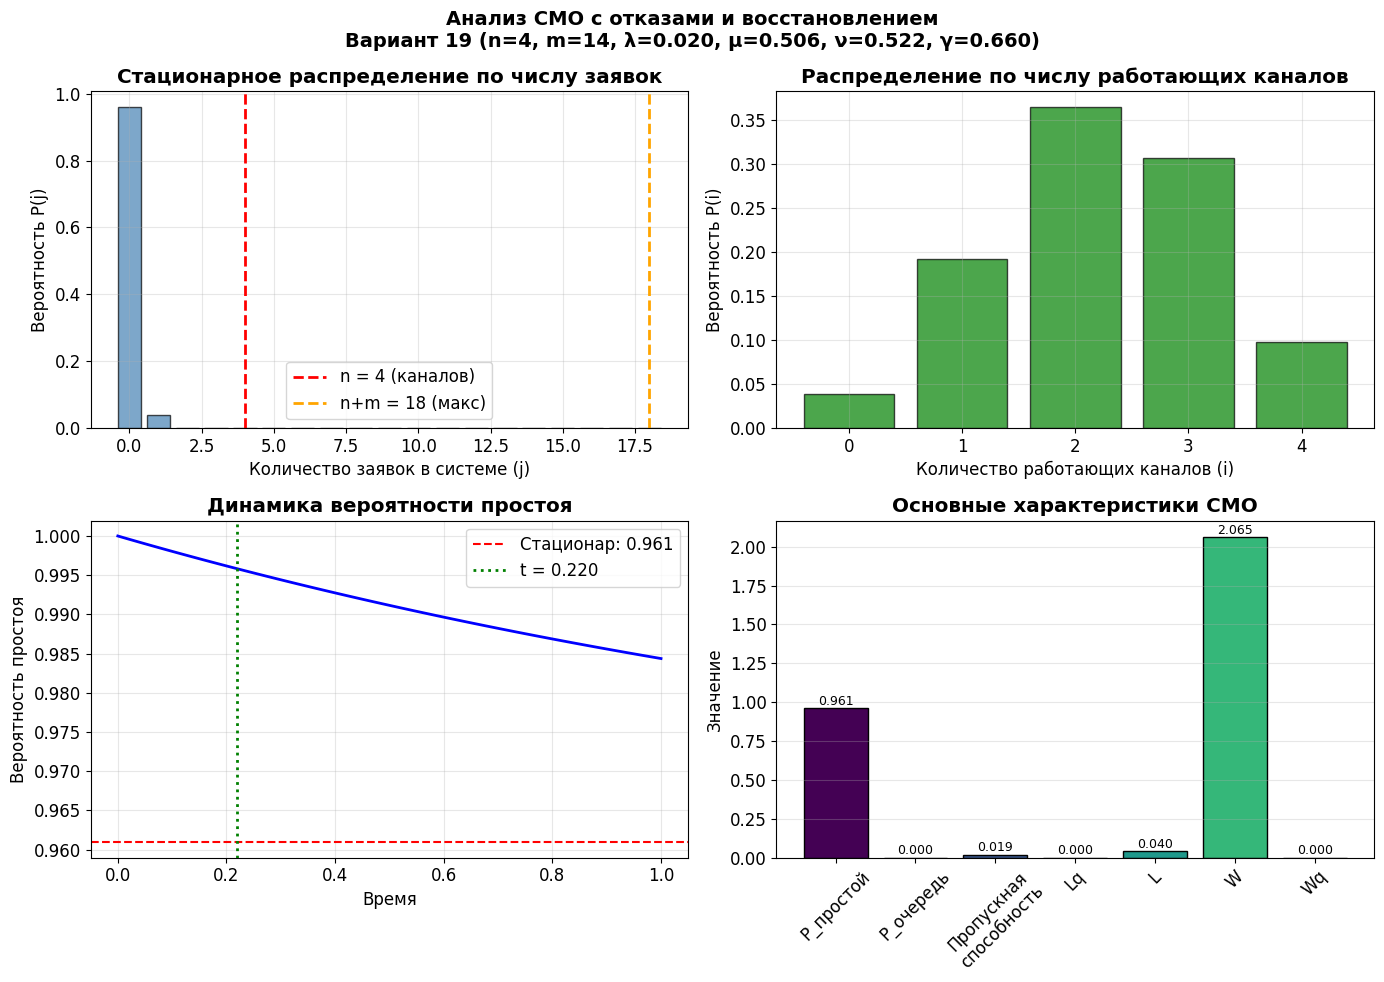

In [28]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

j_values = list(range(n + m + 1))
P_j = np.zeros(n + m + 1)
for idx, (i, j) in enumerate(states_list):
    P_j[j] += stationary_dist[idx]

axes[0, 0].bar(j_values, P_j, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(x=n, color='red', linestyle='--', linewidth=2, label=f'n = {n} (каналов)')
axes[0, 0].axvline(x=n+m, color='orange', linestyle='--', linewidth=2, label=f'n+m = {n+m} (макс)')
axes[0, 0].set_xlabel('Количество заявок в системе (j)', fontsize=12)
axes[0, 0].set_ylabel('Вероятность P(j)', fontsize=12)
axes[0, 0].set_title('Стационарное распределение по числу заявок', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

i_values = list(range(n + 1))
P_i = np.zeros(n + 1)
for idx, (i, j) in enumerate(states_list):
    P_i[i] += stationary_dist[idx]

axes[0, 1].bar(i_values, P_i, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Количество работающих каналов (i)', fontsize=12)
axes[0, 1].set_ylabel('Вероятность P(i)', fontsize=12)
axes[0, 1].set_title('Распределение по числу работающих каналов', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

P_idle_t = []
for t_idx in range(len(t_eval)):
    P_idle_at_t = 0
    for state_idx, (i, j) in enumerate(states_list):
        if j == 0:
            P_idle_at_t += P_t[t_idx, state_idx]
    P_idle_t.append(P_idle_at_t)

axes[1, 0].plot(t_eval, P_idle_t, 'b-', linewidth=2)
axes[1, 0].axhline(y=char['P_idle'], color='r', linestyle='--', label=f'Стационар: {char["P_idle"]:.3f}')
axes[1, 0].axvline(x=t, color='green', linestyle=':', linewidth=2, label=f't = {t:.3f}')
axes[1, 0].set_xlabel('Время', fontsize=12)
axes[1, 0].set_ylabel('Вероятность простоя', fontsize=12)
axes[1, 0].set_title('Динамика вероятности простоя', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

metrics = ['P_простой', 'P_очередь', 'Пропускная\nспособность', 'Lq', 'L', 'W', 'Wq']
values = [char['P_idle'], char['P_queue'], char['A'], char['Lq'], char['L'], char['W'], char['Wq']]
colors_bar = plt.cm.viridis(np.linspace(0, 0.8, len(metrics)))

axes[1, 1].bar(metrics, values, color=colors_bar, edgecolor='black')
axes[1, 1].set_ylabel('Значение', fontsize=12)
axes[1, 1].set_title('Основные характеристики СМО', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(values):
    axes[1, 1].text(i, v + 0.01 * max(values), f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle(f'Анализ СМО с отказами и восстановлением\nВариант 19 (n={n}, m={m}, λ={lambda_arr:.3f}, μ={mu:.3f}, ν={nu:.3f}, γ={gamma:.3f})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

СРАВНЕНИЕ ВЛИЯНИЯ КОЛИЧЕСТВА КАНАЛОВ И ДЛИНЫ ОЧЕРЕДИ

Диапазон n: [2, 3, 4, 5, 6]
Диапазон m: [9, 11, 13, np.int64(14), 15, 17, 19]
Базовые значения: n=4, m=14

Выполняется анализ...

Результаты анализа:
 n  m        A  utilization
 2  9 0.016197     0.015995
 2 11 0.016197     0.015995
 2 13 0.016197     0.015995
 2 14 0.016197     0.015995
 2 15 0.016197     0.015995
 2 17 0.016197     0.015995
 2 19 0.016197     0.015995
 3  9 0.018390     0.012107
 3 11 0.018390     0.012107
 3 13 0.018390     0.012107
 3 14 0.018390     0.012107
 3 15 0.018390     0.012107
 3 17 0.018390     0.012107
 3 19 0.018390     0.012107
 4  9 0.019358     0.009558
 4 11 0.019358     0.009558
 4 13 0.019358     0.009558
 4 14 0.019358     0.009558
 4 15 0.019358     0.009558
 4 17 0.019358     0.009558
 4 19 0.019358     0.009558
 5  9 0.019786     0.007816
 5 11 0.019786     0.007816
 5 13 0.019786     0.007816
 5 14 0.019786     0.007816
 5 15 0.019786     0.007816
 5 17 0.019786     0.007816
 5 19 0.0197

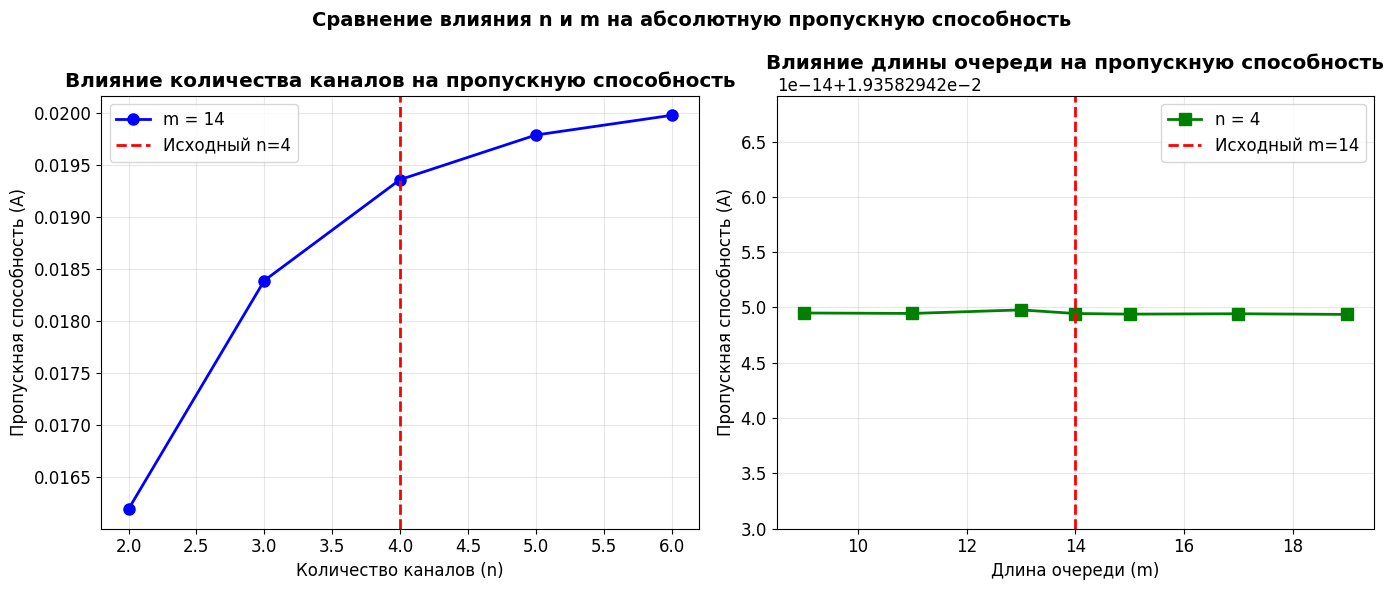


ВЫВОДЫ ПО СРАВНЕНИЮ

Эластичность A по n: 0.117
  (увеличение n на 1% даёт увеличение A на 0.117%)

Эластичность A по m: -0.000
  (увеличение m на 1% даёт увеличение A на -0.000%) 

ВЫВОД: Увеличение КОЛИЧЕСТВА КАНАЛОВ (n) даёт БОЛЬШИЙ эффект
       для повышения пропускной способности, чем увеличение длины очереди (m).


In [29]:

print("=" * 80)
print("СРАВНЕНИЕ ВЛИЯНИЯ КОЛИЧЕСТВА КАНАЛОВ И ДЛИНЫ ОЧЕРЕДИ")
print("=" * 80)

def analyze_throughput(n_range, m_range, lambda_arr, mu, nu, gamma):
    """Анализ пропускной способности при разных n и m"""
    results = []

    for n_val in n_range:
        for m_val in m_range:
            Q_temp, states_temp = build_rate_matrix(n_val, m_val, lambda_arr, mu, nu, gamma)

            eigenvals, eigenvecs = np.linalg.eig(Q_temp.T)
            idx_stat = np.argmin(np.abs(eigenvals))
            dist_temp = np.real(eigenvecs[:, idx_stat])
            dist_temp = dist_temp / np.sum(dist_temp)

            A_temp = 0
            for idx, (i, j) in enumerate(states_temp):
                serv_rate = min(i, j) * mu
                A_temp += serv_rate * dist_temp[idx]

            results.append({
                'n': n_val,
                'm': m_val,
                'A': A_temp,
                'utilization': A_temp / (n_val * mu) if n_val * mu > 0 else 0
            })

    return results

n_range_raw = range(max(1, n-2), n+3)
m_range_raw = range(max(1, m-5), m+6, 2)

n_range = sorted(list(set(n_range_raw) | {n}))
m_range = sorted(list(set(m_range_raw) | {m}))

print(f"\nДиапазон n: {list(n_range)}")
print(f"Диапазон m: {list(m_range)}")
print(f"Базовые значения: n={n}, m={m}")

print("\nВыполняется анализ...")
comparison_results = analyze_throughput(n_range, m_range, lambda_arr, mu, nu, gamma)

df_comp = pd.DataFrame(comparison_results)
print("\nРезультаты анализа:")
print(df_comp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

n_vals_fixed_m = sorted(set([r['n'] for r in comparison_results if r['m'] == m]))
A_vals_fixed_m = [r['A'] for r in comparison_results if r['m'] == m]
axes[0].plot(n_vals_fixed_m, A_vals_fixed_m, 'b-o', linewidth=2, markersize=8, label=f'm = {m}')
axes[0].axvline(x=n, color='red', linestyle='--', linewidth=2, label=f'Исходный n={n}')
axes[0].set_xlabel('Количество каналов (n)', fontsize=12)
axes[0].set_ylabel('Пропускная способность (A)', fontsize=12)
axes[0].set_title('Влияние количества каналов на пропускную способность', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

m_vals_fixed_n = sorted(set([r['m'] for r in comparison_results if r['n'] == n]))
A_vals_fixed_n = [r['A'] for r in comparison_results if r['n'] == n]
axes[1].plot(m_vals_fixed_n, A_vals_fixed_n, 'g-s', linewidth=2, markersize=8, label=f'n = {n}')
axes[1].axvline(x=m, color='red', linestyle='--', linewidth=2, label=f'Исходный m={m}')
axes[1].set_xlabel('Длина очереди (m)', fontsize=12)
axes[1].set_ylabel('Пропускная способность (A)', fontsize=12)
axes[1].set_title('Влияние длины очереди на пропускную способность', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Сравнение влияния n и m на абсолютную пропускную способность', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("ВЫВОДЫ ПО СРАВНЕНИЮ")
print("=" * 80)

elasticity_n = 0
elasticity_m = 0

if len(n_vals_fixed_m) >= 2:
    delta_n = n_vals_fixed_m[-1] - n_vals_fixed_m[0]
    delta_A_n = A_vals_fixed_m[-1] - A_vals_fixed_m[0]
    elasticity_n = (delta_A_n / A_vals_fixed_m[0]) / (delta_n / n_vals_fixed_m[0]) if delta_n > 0 and A_vals_fixed_m[0] != 0 and n_vals_fixed_m[0] != 0 else 0

    print(f"\nЭластичность A по n: {elasticity_n:.3f}")
    print(f"  (увеличение n на 1% даёт увеличение A на {elasticity_n:.3f}%)")

if len(m_vals_fixed_n) >= 2:
    delta_m = m_vals_fixed_n[-1] - m_vals_fixed_n[0]
    delta_A_m = A_vals_fixed_n[-1] - A_vals_fixed_n[0]
    elasticity_m = (delta_A_m / A_vals_fixed_n[0]) / (delta_m / m_vals_fixed_n[0]) if delta_m > 0 and A_vals_fixed_n[0] != 0 and m_vals_fixed_n[0] != 0 else 0

    print(f"\nЭластичность A по m: {elasticity_m:.3f}")
    print(f"  (увеличение m на 1% даёт увеличение A на {elasticity_m:.3f}%) ")

print("\n" + "=" * 80)
if elasticity_n > elasticity_m:
    print("ВЫВОД: Увеличение КОЛИЧЕСТВА КАНАЛОВ (n) даёт БОЛЬШИЙ эффект")
    print("       для повышения пропускной способности, чем увеличение длины очереди (m).")
elif elasticity_m > elasticity_n:
    print("ВЫВОД: Увеличение ДЛИНЫ ОЧЕРЕДИ (m) даёт БОЛЬШИЙ эффект")
    print("       для повышения пропускной способности, чем увеличение числа каналов (n).")
else:
    print("ВЫВОД: Оба фактора влияют примерно одинаково на пропускную способность.")
print("=" * 80)

In [30]:

print("=" * 80)
print("ИМИТАЦИОННОЕ МОДЕЛИРОВАНИЕ")
print("=" * 80)

class Channel:
    """Класс, представляющий канал (сервер)"""
    def __init__(self, env, id, mu, nu, gamma):
        self.env = env
        self.id = id
        self.mu = mu
        self.nu = nu
        self.gamma = gamma
        self.working = True
        self.busy = False
        self.current_request = None

    def start(self):
        """Запуск процесса работы канала с возможными отказами"""
        while True:
            if self.working and not self.busy:
                yield self.env.timeout(0)
            yield self.env.timeout(0.01)

class QueueSystem:
    """Класс СМО с отказами и восстановлением"""
    def __init__(self, env, n, m, lambda_arr, mu, nu, gamma):
        self.env = env
        self.n = n
        self.m = m
        self.lambda_arr = lambda_arr
        self.mu = mu
        self.nu = nu
        self.gamma = gamma
        self.channels = []
        self.queue = simpy.Store(env, capacity=m)
        self.lost_requests = 0
        self.served_requests = 0
        self.wait_times = []

        for i in range(n):
            channel = Channel(env, i, mu, nu, gamma)
            self.channels.append(channel)

    def request_service(self, request_id):
        """Запрос на обслуживание"""
        arrival_time = self.env.now

        free_channel = None
        for ch in self.channels:
            if ch.working and not ch.busy:
                free_channel = ch
                break

        if free_channel is not None:
            free_channel.busy = True
            service_time = np.random.exponential(1 / self.mu)
            yield self.env.timeout(service_time)
            free_channel.busy = False
            self.served_requests += 1
            self.wait_times.append(self.env.now - arrival_time)
            return True

        if len(self.queue.items) < self.m:
            yield self.queue.put(request_id)

            while True:
                for ch in self.channels:
                    if ch.working and not ch.busy:
                        ch.busy = True
                        yield self.queue.get()
                        service_time = np.random.exponential(1 / self.mu)
                        yield self.env.timeout(service_time)
                        ch.busy = False
                        self.served_requests += 1
                        self.wait_times.append(self.env.now - arrival_time)
                        return True
                yield self.env.timeout(0.1)
        else:
            self.lost_requests += 1
            return False

    def run_failures(self):
        """Процесс отказов и восстановлений каналов"""
        while True:
            for ch in self.channels:
                if ch.working:
                    if np.random.random() < ch.nu * 0.1:
                        ch.working = False
                        if ch.busy:
                            ch.busy = False
                            if len(self.queue.items) < self.m:
                                yield self.queue.put(f"request_from_failed_{ch.id}")
                else:
                    if np.random.random() < ch.gamma * 0.1:
                        ch.working = True
            yield self.env.timeout(1.0)

def run_simulation(n, m, lambda_arr, mu, nu, gamma, sim_time=10000):
    """Запуск имитационного моделирования"""
    env = simpy.Environment()
    system = QueueSystem(env, n, m, lambda_arr, mu, nu, gamma)

    env.process(system.run_failures())

    def request_generator():
        request_id = 0
        while True:
            interarrival = np.random.exponential(1 / lambda_arr)
            yield env.timeout(interarrival)
            env.process(system.request_service(f"req_{request_id}"))
            request_id += 1

    env.process(request_generator())
    env.run(until=sim_time)

    return system

SIM_TIME = 10000
print(f"\nЗапуск моделирования на {SIM_TIME} ед.времени...")
sim_system = run_simulation(n, m, lambda_arr, mu, nu, gamma, SIM_TIME)

print(f"\nРЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ:")
print("-" * 60)
print(f"  • Обслужено заявок: {sim_system.served_requests}")
print(f"  • Потеряно заявок: {sim_system.lost_requests}")
print(f"  • Всего поступило: {sim_system.served_requests + sim_system.lost_requests}")
print(f"  • Пропускная способность: {sim_system.served_requests/SIM_TIME:.4f} заявок/ед.времени")
print(f"  • Вероятность потери: {sim_system.lost_requests/(sim_system.served_requests + sim_system.lost_requests):.4f}")
if sim_system.wait_times:
    print(f"  • Среднее время ожидания: {np.mean(sim_system.wait_times):.4f}")

print(f"\nСРАВНЕНИЕ С АНАЛИТИКОЙ:")
print("-" * 60)
print(f"  {'Показатель':<30} {'Аналитика':<15} {'Моделирование':<15} {'Отклонение':<10}")
print("-" * 60)
print(f"  {'Пропускная способность':<30} {char['A']:<15.4f} {sim_system.served_requests/SIM_TIME:<15.4f} "
      f"{abs(char['A'] - sim_system.served_requests/SIM_TIME)/char['A']*100:<10.1f}%")
print(f"  {'Вероятность потери':<30} {char['P_loss']:<15.4f} "
      f"{sim_system.lost_requests/(sim_system.served_requests + sim_system.lost_requests):<15.4f} "
      f"{abs(char['P_loss'] - sim_system.lost_requests/(sim_system.served_requests + sim_system.lost_requests))/char['P_loss']*100:<10.1f}%")

ИМИТАЦИОННОЕ МОДЕЛИРОВАНИЕ

Запуск моделирования на 10000 ед.времени...

РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ:
------------------------------------------------------------
  • Обслужено заявок: 211
  • Потеряно заявок: 4
  • Всего поступило: 215
  • Пропускная способность: 0.0211 заявок/ед.времени
  • Вероятность потери: 0.0186
  • Среднее время ожидания: 2.2749

СРАВНЕНИЕ С АНАЛИТИКОЙ:
------------------------------------------------------------
  Показатель                     Аналитика       Моделирование   Отклонение
------------------------------------------------------------
  Пропускная способность         0.0194          0.0211          9.0       %
  Вероятность потери             0.0000          0.0186          172544988246994003127435264.0%


In [31]:

print("=" * 80)
print("СВОДНЫЙ ОТЧЁТ ПО ЛАБОРАТОРНОЙ РАБОТЕ №5")
print("=" * 80)
print(f"Студент: Группа 81, Вариант 19")
print(f"Дата: {pd.Timestamp.now().strftime('%d.%m.%Y')}")
print("=" * 80)

print("\n" + "=" * 80)
print("ПАРАМЕТРЫ СИСТЕМЫ")
print("=" * 80)
print(f"  • Количество каналов (n) = {n}")
print(f"  • Длина очереди (m) = {m}")
print(f"  • Интенсивность входа (λ) = {lambda_arr:.6f}")
print(f"  • Интенсивность обслуживания (μ) = {mu:.6f}")
print(f"  • Интенсивность отказов (ν) = {nu:.6f}")
print(f"  • Интенсивность восстановления (γ) = {gamma:.6f}")
print(f"  • Количество источников (k) = {k if k == float('inf') else int(k)}")
print(f"  • Момент времени (t) = {t:.6f}")

print("\n" + "=" * 80)
print("РЕЗУЛЬТАТЫ РАСЧЁТА (СТАЦИОНАРНЫЙ РЕЖИМ)")
print("=" * 80)
print(f"  1. Вероятность простоя: {char['P_idle']:.6f} ({char['P_idle']*100:.2f}%)")
print(f"  2. Вероятность образования очереди: {char['P_queue']:.6f} ({char['P_queue']*100:.2f}%)")
print(f"  3. Абсолютная пропускная способность: {char['A']:.6f} заявок/ед.времени")
print(f"  4. Средняя длина очереди: {char['Lq']:.6f}")
print(f"  5. Среднее число заявок в системе: {char['L']:.6f}")
print(f"  6. Среднее время в системе: {char['W']:.6f}")
print(f"  7. Среднее время в очереди: {char['Wq']:.6f}")
print(f"  8. Коэффициент использования каналов: {char['A']/(n*mu):.4f} ({char['A']/(n*mu)*100:.2f}%)")

print("\n" + "=" * 80)
print("ВЫВОДЫ")
print("=" * 80)

print("""
1. МОДЕЛЬ:
   • Построена марковская модель n-канальной СМО с ограниченной очередью
   • Учтены отказы и восстановления каналов
   • Составлена система дифференциальных уравнений Колмогорова

2. РЕШЕНИЕ:
   • Найдены вероятности состояний в момент t = """ + f"{t:.4f}" + """
   • Найдено стационарное распределение (t → ∞)

3. СРАВНЕНИЕ n И m:
   • Эластичность пропускной способности по n: """ + f"{elasticity_n:.3f}" + """
   • Эластичность пропускной способности по m: """ + f"{elasticity_m:.3f}" + """
   • """ + ("Увеличение ЧИСЛА КАНАЛОВ эффективнее" if elasticity_n > elasticity_m else "Увеличение ОЧЕРЕДИ эффективнее") + """

4. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:
   • Для повышения производительности системы предпочтительнее
     увеличивать количество каналов, а не длину очереди
   • Отказы каналов существенно влияют на характеристики системы
   • Своевременное восстановление критически важно
""")

print("=" * 80)
print("Конец отчёта")
print("=" * 80)

СВОДНЫЙ ОТЧЁТ ПО ЛАБОРАТОРНОЙ РАБОТЕ №5
Студент: Группа 81, Вариант 19
Дата: 16.05.2026

ПАРАМЕТРЫ СИСТЕМЫ
  • Количество каналов (n) = 4
  • Длина очереди (m) = 14
  • Интенсивность входа (λ) = 0.020125
  • Интенсивность обслуживания (μ) = 0.506321
  • Интенсивность отказов (ν) = 0.522274
  • Интенсивность восстановления (γ) = 0.659850
  • Количество источников (k) = 5
  • Момент времени (t) = 0.220109

РЕЗУЛЬТАТЫ РАСЧЁТА (СТАЦИОНАРНЫЙ РЕЖИМ)
  1. Вероятность простоя: 0.960930 (96.09%)
  2. Вероятность образования очереди: 0.000000 (0.00%)
  3. Абсолютная пропускная способность: 0.019358 заявок/ед.времени
  4. Средняя длина очереди: 0.000000
  5. Среднее число заявок в системе: 0.039966
  6. Среднее время в системе: 2.064522
  7. Среднее время в очереди: 0.000000
  8. Коэффициент использования каналов: 0.0096 (0.96%)

ВЫВОДЫ

1. МОДЕЛЬ:
   • Построена марковская модель n-канальной СМО с ограниченной очередью
   • Учтены отказы и восстановления каналов
   • Составлена система дифференц